# Анализ эксперимента с нейроинтерфейсом Neiry
## Исследование эффективности приложения эмоциональной регуляции

Этот ноутбук анализирует данные, собранные во время эксперимента с респондентом.

**Что вы получите:**
- Визуализацию ЭЭГ сигналов по фазам эксперимента
- Графики динамики метрик: стресс (activity), фокус (attention), расслабленность (meditation)
- Сравнительную таблицу средних значений по фазам
- Статистическую оценку значимости различий

**Необходимые файлы:**
- BDF файл из папки `converted/`
- Файл с временными метками `times_*.txt`

In [13]:
# Ячейка 1: Импорт библиотек

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob
import shutil

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Библиотеки загружены")
print(f"MNE-Python версия: {mne.__version__}")

Библиотеки загружены
MNE-Python версия: 1.12.1


In [14]:
# Ячейка 2: Автоматическое определение сессии и загрузка данных

# Папки проекта
RAW_DIR = "raw_data"
EVENTS_DIR = "events"
CONVERTED_DIR = "converted"
RESULTS_DIR = "results"

# Создаём папки, если их нет
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(EVENTS_DIR, exist_ok=True)
os.makedirs(CONVERTED_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def find_session():
    """Находит все доступные сессии (пары bdf + events)"""
    sessions = []
    
    # Ищем все bdf файлы в converted/
    bdf_files = glob.glob(os.path.join(CONVERTED_DIR, "*.bdf"))
    
    for bdf_path in bdf_files:
        base_name = os.path.splitext(os.path.basename(bdf_path))[0]
        events_path = os.path.join(EVENTS_DIR, f"{base_name}.txt")
        
        sessions.append({
            'name': base_name,
            'bdf_path': bdf_path,
            'events_path': events_path if os.path.exists(events_path) else None
        })
    
    return sessions

# Находим все сессии
sessions = find_session()

if not sessions:
    print("❌ Нет сконвертированных .bdf файлов в папке converted/")
    print("   Сначала запустите python convert.py")
else:
    print(f"Найдено {len(sessions)} сессий:")
    for i, s in enumerate(sessions):
        events_status = "✅" if s['events_path'] else "⚠️"
        print(f"  [{i}] {s['name']} {events_status}")
    
    # Выбираем последнюю сессию (или предлагаем выбрать)
    if len(sessions) == 1:
        selected = sessions[0]
    else:
        try:
            idx = int(input(f"\nВыберите номер сессии для анализа [0-{len(sessions)-1}]: "))
            selected = sessions[idx]
        except:
            print("Использую последнюю сессию")
            selected = sessions[-1]
    
    print(f"\n✅ Выбрана сессия: {selected['name']}")
    
    # Загружаем BDF файл
    raw = mne.io.read_raw_bdf(selected['bdf_path'], preload=True)
    
    # Переименовываем каналы при необходимости
    mapping = {}
    raw.rename_channels(mapping)
    
    # Устанавливаем типы каналов
    eeg_channels = ['O1', 'O2', 'T3', 'T4']
    misc_channels = ['activity', 'attention', 'relaxation', 'alpha', 'beta', 'theta', 'delta']
    
    raw.set_channel_types({ch: 'eeg' for ch in eeg_channels if ch in raw.ch_names})
    raw.set_channel_types({ch: 'misc' for ch in misc_channels if ch in raw.ch_names})
    
    print(f"Данные загружены. Длительность: {raw.times[-1]:.1f} сек, каналов: {len(raw.ch_names)}")
    
    # Создаём папку для результатов этой сессии
    session_results_dir = os.path.join(RESULTS_DIR, selected['name'])
    os.makedirs(session_results_dir, exist_ok=True)
    print(f"📁 Результаты будут сохранены в: {session_results_dir}")
    
    # Сохраняем информацию о сессии для других ячеек
    SESSION_INFO = {
        'name': selected['name'],
        'events_path': selected['events_path'],
        'results_dir': session_results_dir
    }

Найдено 1 сессий:
  [0] session_20260427_000835 ✅

✅ Выбрана сессия: session_20260427_000835
Extracting BDF parameters from converted\session_20260427_000835.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 58499  =      0.000 ...   233.996 secs...
Данные загружены. Длительность: 234.0 сек, каналов: 9
📁 Результаты будут сохранены в: results\session_20260427_000835


C:\Users\pheni\AppData\Local\Temp\ipykernel_40760\1447062267.py:71: RuntimeWarning: The unit for channel(s) activity, alpha, attention, beta, delta, relaxation, theta has changed from V to NA.
  raw.set_channel_types({ch: 'misc' for ch in misc_channels if ch in raw.ch_names})


In [15]:
# Ячейка 3: Загрузка временных меток

def load_times_from_log(log_file):
    times = {}
    if not os.path.exists(log_file):
        print(f"Файл не найден: {log_file}")
        return None
    
    with open(log_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if ':' in line and not line.startswith('#'):
                parts = line.split(':', 1)
                if len(parts) == 2:
                    key = parts[0].strip()
                    try:
                        value = float(parts[1].strip())
                        times[key] = value
                    except ValueError:
                        pass
    return times if times else None

# Загружаем времена из файла событий
TIMES = None

if SESSION_INFO['events_path'] and os.path.exists(SESSION_INFO['events_path']):
    print(f"✅ Загружаем временные метки из: {SESSION_INFO['events_path']}")
    loaded_times = load_times_from_log(SESSION_INFO['events_path'])
    if loaded_times:
        TIMES = loaded_times
else:
    print(f"⚠️ Файл событий не найден: {SESSION_INFO['events_path']}")

if TIMES:
    print("\n📋 Временные метки загружены из файла:")
    for key, val in TIMES.items():
        if isinstance(val, (int, float)) and val >= 0:
            print(f"  {key}: {val:.1f} сек")
else:
    # Ручной ввод
    print("\n⚠️ Файл с метками не найден. Введите времена вручную:")
    print("(нажмите ENTER для значений по умолчанию)\n")
    
    duration = raw.times[-1]
    default_end = min(duration * 0.8, 60)
    
    TIMES = {
        'T0_start_recording': 0.0,
        'T1_baseline_end': float(input(f"  T1_baseline_end (сек) [10]: ") or 10),
        'T2_walk_start': float(input(f"  T2_walk_start (сек) [20]: ") or 20),
        'T3_walk_end': float(input(f"  T3_walk_end (сек) [30]: ") or 30),
        'T4_exercise_start': float(input(f"  T4_exercise_start (сек) [35]: ") or 35),
        'T5_exercise_end': float(input(f"  T5_exercise_end (сек) [45]: ") or 45),
        'T6_recovery_end': float(input(f"  T6_recovery_end (сек) [55]: ") or 55),
        'T7_stop_recording': float(input(f"  T7_stop_recording (сек) [{default_end:.0f}]: ") or default_end),
    }

required_keys = ['T0_start_recording', 'T1_baseline_end', 'T2_walk_start', 'T3_walk_end',
                 'T4_exercise_start', 'T5_exercise_end', 'T6_recovery_end', 'T7_stop_recording']

for key in required_keys:
    if key not in TIMES:
        TIMES[key] = 0.0

print("\n✅ Временные метки загружены и готовы к использованию")
print(f"   Длительность эксперимента: {TIMES['T7_stop_recording']:.0f} сек")

✅ Загружаем временные метки из: events\session_20260427_000835.txt

📋 Временные метки загружены из файла:
  session_start_unix: 1777237715.1 сек
  T0_start_recording: 0.0 сек
  T1_baseline_end: 51.0 сек
  T2_walk_start: 82.0 сек
  T3_walk_end: 120.1 сек
  T4_exercise_start: 123.8 сек
  T5_exercise_end: 139.0 сек
  T6_recovery_end: 146.8 сек
  T7_stop_recording: 155.6 сек

✅ Временные метки загружены и готовы к использованию
   Длительность эксперимента: 156 сек


In [16]:
# Ячейка 4: Аннотация фаз эксперимента (с проверкой границ данных)

# Получаем реальную длительность записи
if 'raw' not in dir():
    print("Данные не загружены. Сначала выполните ячейку 2.")
else:
    max_duration = raw.times[-1]
    print(f"Реальная длительность записи: {max_duration:.1f} сек")

    # Определяем фазы эксперимента, но только те, которые попадают в пределы записи
    phase_definitions = [
        ('baseline', TIMES['T0_start_recording'], TIMES['T1_baseline_end'], 'Спокойное состояние'),
        ('free_walk', TIMES['T2_walk_start'], TIMES['T3_walk_end'], 'Свободная прогулка'),
        ('exercise', TIMES['T4_exercise_start'], TIMES['T5_exercise_end'], 'Упражнение'),
        ('recovery', TIMES['T5_exercise_end'], TIMES['T6_recovery_end'], 'Восстановление')
    ]
    
    # Фильтруем фазы: оставляем только те, которые в пределах записи
    valid_phases = []
    annotations_list = []
    
    for name, start, end, desc in phase_definitions:
        if end <= start:
            print(f"  ⚠️ Пропускаем '{name}': start({start:.0f}) >= end({end:.0f})")
            continue
        if start > max_duration:
            print(f"  ⚠️ Пропускаем '{name}': start({start:.0f}) > длительность({max_duration:.0f})")
            continue
        if end < 0:
            continue
        
        # Обрезаем end, если он выходит за пределы записи
        original_end = end
        if end > max_duration:
            end = max_duration
            print(f"  ⚠️ Фаза '{name}' обрезана: {original_end:.0f} -> {end:.0f} сек (макс. длительность)")
        
        valid_phases.append((name, start, end, desc))
        annotations_list.append([start, end - start, name])
    
    if not annotations_list:
        print("\n⚠️ Нет валидных фаз для аннотации. Создаю одну фазу на всю запись.")
        annotations_list.append([0, max_duration, 'recording'])
    
    # Создаём аннотации MNE
    annotations = mne.Annotations(
        onset=[a[0] for a in annotations_list],
        duration=[a[1] for a in annotations_list],
        description=[a[2] for a in annotations_list]
    )
    
    raw.set_annotations(annotations)
    
    print("\nФазы эксперимента размечены:\n")
    for name, start, end, desc in valid_phases:
        print(f"  {name}: {start:.0f} - {end:.0f} сек ({desc})")
    
    # Сохраняем phases для использования в других ячейках
    phases = valid_phases

Реальная длительность записи: 234.0 сек

Фазы эксперимента размечены:

  baseline: 0 - 51 сек (Спокойное состояние)
  free_walk: 82 - 120 сек (Свободная прогулка)
  exercise: 124 - 139 сек (Упражнение)
  recovery: 139 - 147 сек (Восстановление)


In [17]:
# Ячейка 5: Базовый обзор данных

print("=" * 50)
print("ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("=" * 50)

# Информация о каналах
print(f"\nКаналы в данных ({len(raw.ch_names)}):")
for i, ch in enumerate(raw.ch_names):
    if ch in ['activity', 'attention', 'meditation']:
        print(f"  [{i}] {ch} (метрика Neiry)")
    elif ch in ['O1', 'O2', 'T3', 'T4']:
        print(f"  [{i}] {ch} (ЭЭГ канал)")
    else:
        print(f"  [{i}] {ch}")

# Информация о частоте дискретизации
print(f"\nЧастота дискретизации: {raw.info['sfreq']:.1f} Гц")
print(f"Длительность записи: {raw.times[-1]:.1f} сек")
print(f"Фильтры: highpass={raw.info.get('highpass', 'None')}, lowpass={raw.info.get('lowpass', 'None')}")

ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ

Каналы в данных (9):
  [0] O1 (ЭЭГ канал)
  [1] O2 (ЭЭГ канал)
  [2] activity (метрика Neiry)
  [3] attention (метрика Neiry)
  [4] relaxation
  [5] alpha
  [6] beta
  [7] theta
  [8] delta

Частота дискретизации: 250.0 Гц
Длительность записи: 234.0 сек
Фильтры: highpass=0.0, lowpass=125.0


Визуализация ЭЭГ каналов: ['O1', 'O2']


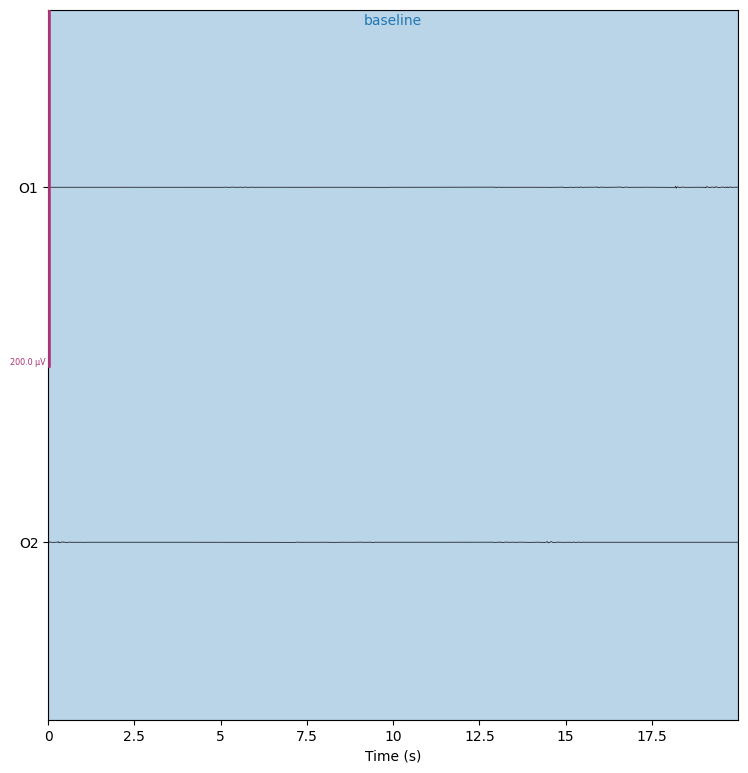


График ЭЭГ открыт в отдельном окне


In [18]:
# Ячейка 6: Визуализация ЭЭГ каналов

# Выбираем только ЭЭГ каналы
eeg_channels = ['O1', 'O2', 'T3', 'T4']
available_eeg = [ch for ch in eeg_channels if ch in raw.ch_names]

if available_eeg:
    print(f"Визуализация ЭЭГ каналов: {available_eeg}")
    # Визуализация с аннотациями фаз
    fig = raw.plot(n_channels=len(available_eeg), 
                   duration=20, 
                   scalings=dict(eeg=100e-6),
                   title="ЭЭГ сигнал по фазам эксперимента",
                   start=0,
                   show_scrollbars=False,
                   block=False)
    print("\nГрафик ЭЭГ открыт в отдельном окне")
else:
    print("ЭЭГ каналы не найдены в данных")

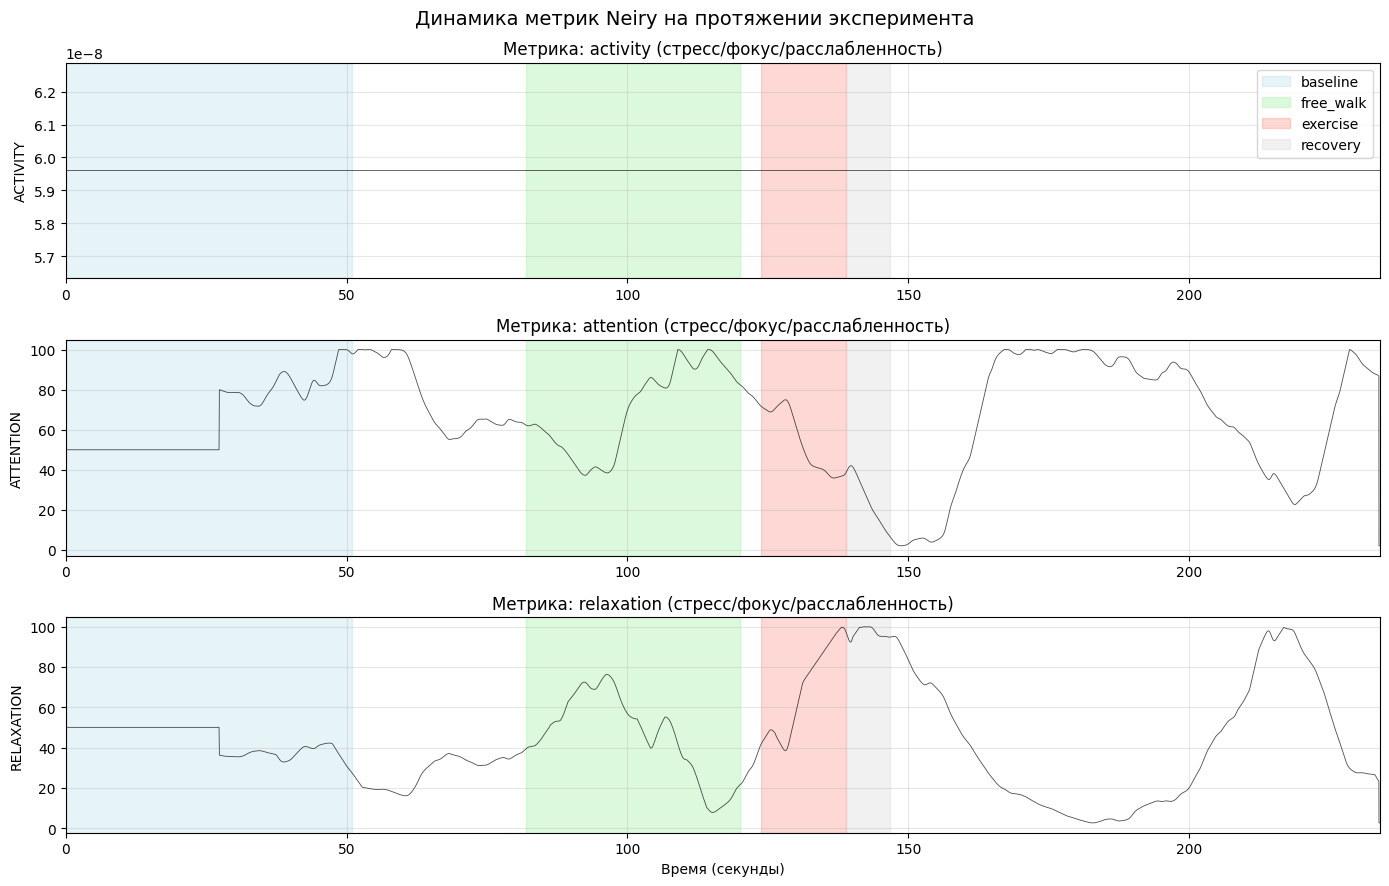

График сохранён как 'metrics_dynamics.png'


In [19]:
# Ячейка 7: Динамика метрик Neiry (общий график)

if 'raw' in dir():
    metrics = ['activity', 'attention', 'relaxation']  # relaxation вместо meditation
    available_metrics = [m for m in metrics if m in raw.ch_names]

    if available_metrics:
        fig, axes = plt.subplots(len(available_metrics), 1, figsize=(14, 3 * len(available_metrics)))
        if len(available_metrics) == 1:
            axes = [axes]
        
        # Цвета для фаз
        phase_colors = {
            'baseline': 'lightblue',
            'free_walk': 'lightgreen',
            'exercise': 'salmon',
            'recovery': 'lightgray'
        }
        
        for i, metric in enumerate(available_metrics):
            ax = axes[i]
            idx = raw.ch_names.index(metric)
            data = raw.get_data(picks=idx)[0]
            times = raw.times
            
            ax.plot(times, data, linewidth=0.6, color='black', alpha=0.7)
            
            # Закрашиваем фазы (только те, что в пределах записи)
            for name, start, end, _ in phases:
                if end > start and start <= raw.times[-1]:
                    color = phase_colors.get(name, 'lightgray')
                    ax.axvspan(start, min(end, raw.times[-1]), alpha=0.3, color=color, label=name if i == 0 else "")
            
            ax.set_ylabel(metric.upper())
            ax.set_xlim(times[0], times[-1])
            ax.grid(True, alpha=0.3)
            ax.set_title(f"Метрика: {metric} (стресс/фокус/расслабленность)")
        
        axes[0].legend(loc='upper right')
        axes[-1].set_xlabel("Время (секунды)")
        plt.suptitle("Динамика метрик Neiry на протяжении эксперимента", fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(SESSION_INFO['results_dir'], "metrics_dynamics.png"), dpi=150, bbox_inches='tight')
        plt.show()
        print("График сохранён как 'metrics_dynamics.png'")
    else:
        print("Метрики Neiry не найдены в данных")
else:
    print("Данные не загружены. Сначала выполните ячейку 2.")


СРЕДНИЕ ЗНАЧЕНИЯ МЕТРИК ПО ФАЗАМ ЭКСПЕРИМЕНТА
metric     activity  attention  relaxation
phase                                     
baseline        0.0    65.0306     43.9724
exercise        0.0    53.9313     68.6070
free_walk       0.0    69.9701     46.0252
recovery        0.0    25.2958     96.9766

Результаты сохранены в 'analysis_results.csv'

  ⚠️ Метрика 'activity' умножена на 1000000 для визуализации (исходные значения очень маленькие)


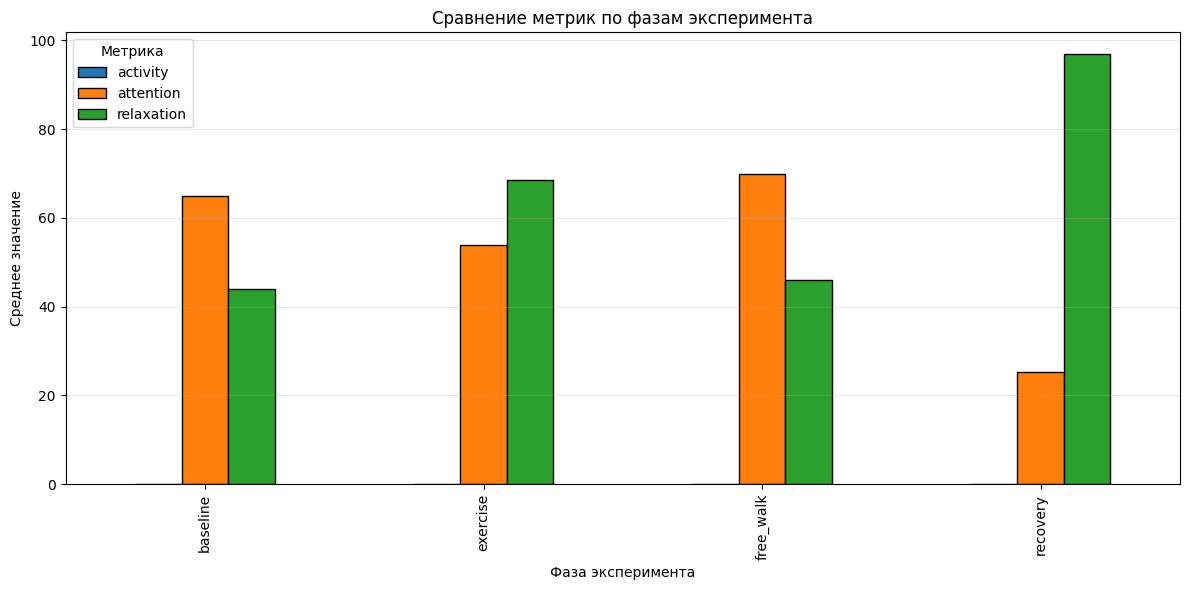


ТАБЛИЦА РЕАЛЬНЫХ ЗНАЧЕНИЙ (без масштабирования)
  baseline - activity: 0.000000 ± 0.000000
  baseline - attention: 65.030571 ± 17.002853
  baseline - relaxation: 43.972404 ± 6.807542
  free_walk - activity: 0.000000 ± 0.000000
  free_walk - attention: 69.970102 ± 21.234641
  free_walk - relaxation: 46.025176 ± 20.206374
  exercise - activity: 0.000000 ± 0.000000
  exercise - attention: 53.931311 ± 15.056970
  exercise - relaxation: 68.606992 ± 21.485881
  recovery - activity: 0.000000 ± 0.000000
  recovery - attention: 25.295779 ± 11.635193
  recovery - relaxation: 96.976569 ± 2.377821


In [20]:
# Ячейка 8: Сводная таблица средних значений по фазам

if 'raw' in dir() and 'available_metrics' in dir() and available_metrics:
    results = []

    for name, start, end, desc in phases:
        if end <= start or start > raw.times[-1]:
            continue
        
        # Обрезаем end, если он выходит за пределы записи
        actual_end = min(end, raw.times[-1])
        
        # Вырезаем фазу
        raw_phase = raw.copy().crop(tmin=start, tmax=actual_end)
        
        for metric in available_metrics:
            if metric in raw_phase.ch_names:
                idx = raw_phase.ch_names.index(metric)
                data = raw_phase.get_data(picks=idx)[0]
                
                results.append({
                    'phase': name,
                    'phase_description': desc,
                    'metric': metric,
                    'mean': np.mean(data),
                    'std': np.std(data),
                    'min': np.min(data),
                    'max': np.max(data),
                    'median': np.median(data)
                })

    df_results = pd.DataFrame(results)

    if not df_results.empty:
        # Сводная таблица (средние значения)
        pivot_mean = df_results.pivot(index='phase', columns='metric', values='mean')
        
        print("\n" + "=" * 60)
        print("СРЕДНИЕ ЗНАЧЕНИЯ МЕТРИК ПО ФАЗАМ ЭКСПЕРИМЕНТА")
        print("=" * 60)
        print(pivot_mean.round(4).to_string())
        
        # Сохраняем результаты
        pivot_mean.to_csv(os.path.join(SESSION_INFO['results_dir'], "analysis_results.csv"))
        print("\nРезультаты сохранены в 'analysis_results.csv'")
        
        # Визуализация средних значений (столбчатая диаграмма)
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Нормализуем данные для лучшей визуализации (если значения слишком маленькие)
        pivot_mean_norm = pivot_mean.copy()
        for col in pivot_mean_norm.columns:
            if pivot_mean_norm[col].max() < 0.01 and pivot_mean_norm[col].max() > 0:
                # Для очень маленьких значений (как activity) умножаем на масштаб
                scale = 1000000  # микро
                pivot_mean_norm[col] = pivot_mean_norm[col] * scale
                print(f"\n  ⚠️ Метрика '{col}' умножена на {scale} для визуализации (исходные значения очень маленькие)")
        
        pivot_mean_norm.plot(kind='bar', ax=ax, edgecolor='black')
        ax.set_xlabel("Фаза эксперимента")
        ax.set_ylabel("Среднее значение")
        ax.set_title("Сравнение метрик по фазам эксперимента")
        ax.legend(title="Метрика")
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(os.path.join(SESSION_INFO['results_dir'], "metrics_comparison.png"), dpi=150, bbox_inches='tight')
        plt.show()
        
        # Дополнительно: таблица с реальными значениями (без масштабирования)
        print("\n" + "=" * 60)
        print("ТАБЛИЦА РЕАЛЬНЫХ ЗНАЧЕНИЙ (без масштабирования)")
        print("=" * 60)
        for idx, row in df_results.iterrows():
            print(f"  {row['phase']} - {row['metric']}: {row['mean']:.6f} ± {row['std']:.6f}")
        
    else:
        print("Нет данных для анализа")
else:
    if 'raw' not in dir():
        print("Данные не загружены. Сначала выполните ячейку 2.")
    elif 'available_metrics' not in dir() or not available_metrics:
        print("Метрики Neiry не найдены в данных")

In [21]:
# Ячейка 9: Статистический анализ (сравнение фаз)

if len(available_metrics) > 0 and 'activity' in raw.ch_names:
    print("\n" + "=" * 60)
    print("СТАТИСТИЧЕСКИЙ АНАЛИЗ: МЕТРИКА СТРЕССА (ACTIVITY)")
    print("=" * 60)
    
    # Собираем данные по активности для каждой фазы
    activity_data = {}
    
    for name, start, end, desc in phases:
        if end <= start:
            continue
        raw_phase = raw.copy().crop(tmin=start, tmax=end)
        if 'activity' in raw_phase.ch_names:
            idx = raw_phase.ch_names.index('activity')
            activity_data[name] = raw_phase.get_data(picks=idx)[0]
    
    # Сравнение с baseline (спокойное состояние)
    if 'baseline' in activity_data:
        baseline = activity_data['baseline']
        
        for name in ['free_walk', 'exercise', 'recovery']:
            if name in activity_data:
                t_stat, p_val = stats.ttest_ind(activity_data[name], baseline)
                
                print(f"\n{name} vs baseline:")
                print(f"  Среднее ({name}):     {np.mean(activity_data[name]):.4f}")
                print(f"  Среднее (baseline):   {np.mean(baseline):.4f}")
                print(f"  Разница:              {np.mean(activity_data[name]) - np.mean(baseline):.4f}")
                print(f"  t-статистика:         {t_stat:.4f}")
                print(f"  p-value:              {p_val:.6f}")
                
                if p_val < 0.05:
                    print(f"  → РАЗЛИЧИЕ СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)")
                else:
                    print(f"  → Различие НЕ значимо (p >= 0.05)")
    else:
        print("Фаза 'baseline' не найдена для сравнения")
        
    # Дополнительно: сравнение exercise vs recovery
    if 'exercise' in activity_data and 'recovery' in activity_data:
        t_stat, p_val = stats.ttest_ind(activity_data['exercise'], activity_data['recovery'])
        print(f"\nСравнение exercise vs recovery:")
        print(f"  t-статистика: {t_stat:.4f}")
        print(f"  p-value: {p_val:.6f}")
        if p_val < 0.05:
            print("  → РАЗЛИЧИЕ СТАТИСТИЧЕСКИ ЗНАЧИМО")
else:
    if 'activity' not in raw.ch_names:
        print("Метрика 'activity' не найдена в данных")


СТАТИСТИЧЕСКИЙ АНАЛИЗ: МЕТРИКА СТРЕССА (ACTIVITY)

free_walk vs baseline:
  Среднее (free_walk):     0.0000
  Среднее (baseline):   0.0000
  Разница:              0.0000
  t-статистика:         nan
  p-value:              nan
  → Различие НЕ значимо (p >= 0.05)

exercise vs baseline:
  Среднее (exercise):     0.0000
  Среднее (baseline):   0.0000
  Разница:              0.0000
  t-статистика:         nan
  p-value:              nan
  → Различие НЕ значимо (p >= 0.05)

recovery vs baseline:
  Среднее (recovery):     0.0000
  Среднее (baseline):   0.0000
  Разница:              0.0000
  t-статистика:         nan
  p-value:              nan
  → Различие НЕ значимо (p >= 0.05)

Сравнение exercise vs recovery:
  t-статистика: nan
  p-value: nan


c:\Users\pheni\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


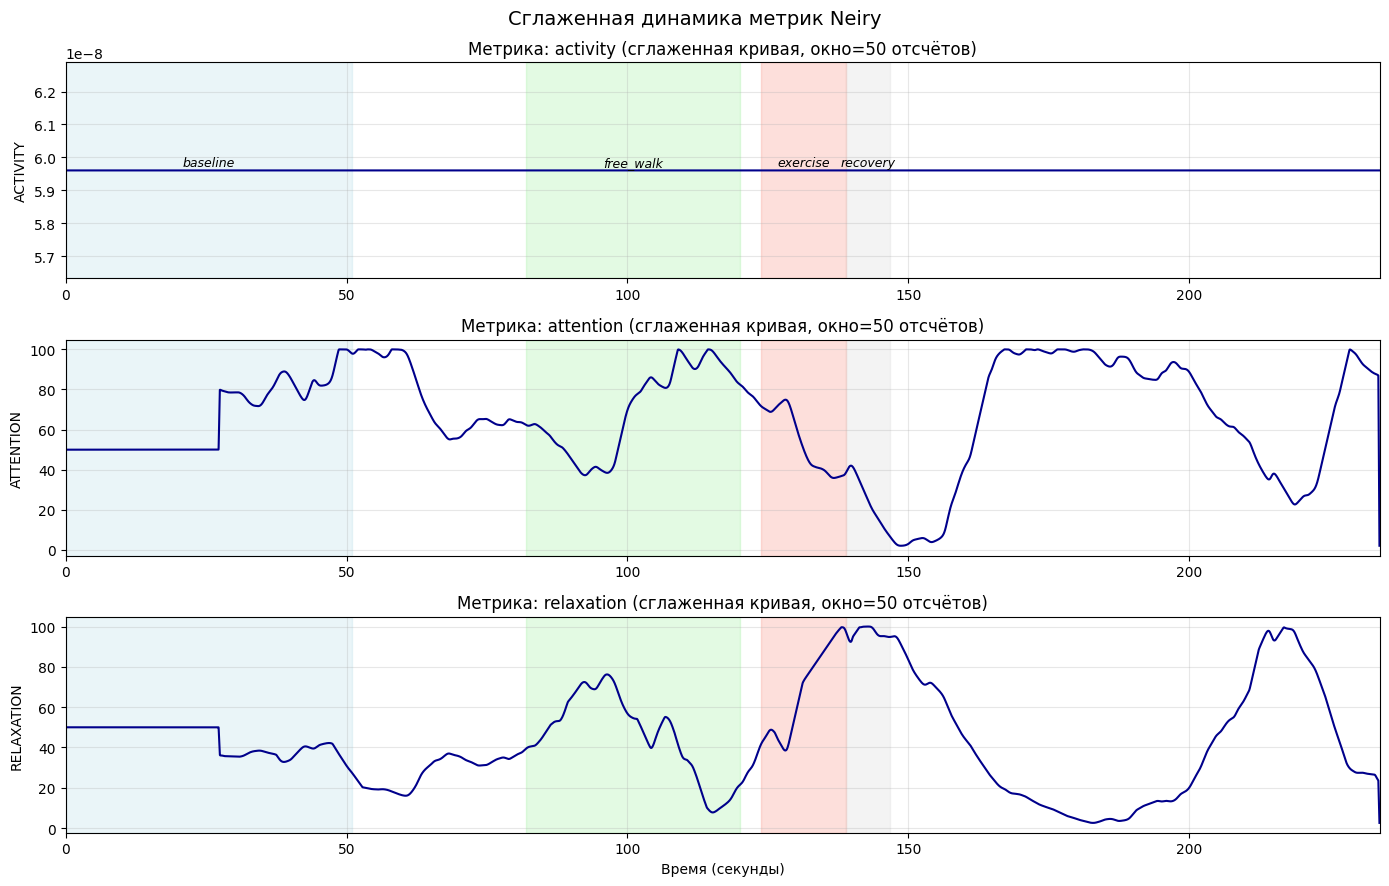

In [22]:
# Ячейка 10: Детальный график по метрикам (сглаженный)

if available_metrics:
    # Параметр сглаживания (скользящее среднее)
    SMOOTH_WINDOW = 50  # количество точек для усреднения
    
    fig, axes = plt.subplots(len(available_metrics), 1, figsize=(14, 3 * len(available_metrics)))
    if len(available_metrics) == 1:
        axes = [axes]
    
    for i, metric in enumerate(available_metrics):
        ax = axes[i]
        idx = raw.ch_names.index(metric)
        data = raw.get_data(picks=idx)[0]
        times = raw.times
        
        # Сглаживание
        smoothed = np.convolve(data, np.ones(SMOOTH_WINDOW)/SMOOTH_WINDOW, mode='valid')
        smoothed_times = times[SMOOTH_WINDOW//2:-SMOOTH_WINDOW//2 + 1]
        
        ax.plot(smoothed_times, smoothed, linewidth=1.5, color='darkblue')
        
        # Закрашиваем фазы
        for name, start, end, desc in phases:
            if end > start:
                color = phase_colors.get(name, 'lightgray')
                ax.axvspan(start, end, alpha=0.25, color=color)
                # Добавляем подписи фаз
                mid = (start + end) / 2
                if i == 0:
                    ax.text(mid, ax.get_ylim()[1] * 0.95, name, 
                            ha='center', fontsize=9, style='italic')
        
        ax.set_ylabel(metric.upper())
        ax.set_xlim(times[0], times[-1])
        ax.grid(True, alpha=0.3)
        ax.set_title(f"Метрика: {metric} (сглаженная кривая, окно={SMOOTH_WINDOW} отсчётов)")
    
    axes[-1].set_xlabel("Время (секунды)")
    plt.suptitle("Сглаженная динамика метрик Neiry", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(SESSION_INFO['results_dir'], "metrics_smoothed.png"), dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
# Ячейка 11: Экспорт результатов в CSV (детальный)

# Создаём подробный датафрейм со всеми данными по времени
if available_metrics:
    detailed_data = pd.DataFrame()
    detailed_data['time_seconds'] = raw.times
    
    for metric in available_metrics:
        idx = raw.ch_names.index(metric)
        detailed_data[metric] = raw.get_data(picks=idx)[0]
    
    # Сохраняем
    detailed_data.to_csv(os.path.join(SESSION_INFO['results_dir'], "detailed_metrics_data.csv"))
    print("Детальные данные по метрикам сохранены в 'detailed_metrics_data.csv'")
    print(f"  {len(detailed_data)} строк, колонки: {list(detailed_data.columns)}")

# Сохраняем сводку по фазам
if not df_results.empty:
    df_results.to_csv(os.path.join(SESSION_INFO['results_dir'], "phase_summary.csv"))
    print("\nСводка по фазам сохранена в 'phase_summary.csv'")

Детальные данные по метрикам сохранены в 'detailed_metrics_data.csv'
  58500 строк, колонки: ['time_seconds', 'activity', 'attention', 'relaxation']

Сводка по фазам сохранена в 'phase_summary.csv'


In [24]:
# Ячейка 12: Итоговый отчёт

print("\n" + "=" * 60)
print("ИТОГОВЫЙ ОТЧЁT ПО ЭКСПЕРИМЕНТУ")
print("=" * 60)

print(f"""
Респондент: [указать код]
Дата эксперимента: [указать дату]

ПАРАМЕТРЫ ЗАПИСИ:
  - Длительность записи: {raw.times[-1]:.1f} сек ({raw.times[-1]/60:.1f} мин)
  - Частота дискретизации: {raw.info['sfreq']:.1f} Гц
  - Количество каналов: {len(raw.ch_names)}
  - ЭЭГ каналы: {available_eeg if available_eeg else 'не найдены'}
  - Метрики Neiry: {available_metrics if available_metrics else 'не найдены'}

ФАЗЫ ЭКСПЕРИМЕНТА:
""")

for name, start, end, desc in phases:
    if end > start:
        print(f"  - {name}: {start:.0f}-{end:.0f} сек ({desc})")

print("\nСОЗДАННЫЕ ФАЙЛЫ:")
files_created = []
for f in ['analysis_results.csv', 'phase_summary.csv', 'detailed_metrics_data.csv',
          'metrics_dynamics.png', 'metrics_comparison.png', 'metrics_smoothed.png']:
    if os.path.exists(f):
        files_created.append(f)

for f in files_created:
    print(f"  - {f}")

print("\n" + "=" * 60)
print("АНАЛИЗ ЗАВЕРШЁН")
print("=" * 60)


ИТОГОВЫЙ ОТЧЁT ПО ЭКСПЕРИМЕНТУ

Респондент: [указать код]
Дата эксперимента: [указать дату]

ПАРАМЕТРЫ ЗАПИСИ:
  - Длительность записи: 234.0 сек (3.9 мин)
  - Частота дискретизации: 250.0 Гц
  - Количество каналов: 9
  - ЭЭГ каналы: ['O1', 'O2']
  - Метрики Neiry: ['activity', 'attention', 'relaxation']

ФАЗЫ ЭКСПЕРИМЕНТА:

  - baseline: 0-51 сек (Спокойное состояние)
  - free_walk: 82-120 сек (Свободная прогулка)
  - exercise: 124-139 сек (Упражнение)
  - recovery: 139-147 сек (Восстановление)

СОЗДАННЫЕ ФАЙЛЫ:

АНАЛИЗ ЗАВЕРШЁН
